In [1]:
import matplotlib.pyplot as plt
import torch
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout
from wandb_trainer import standard_trainer

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "exclude": 'images',
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
#next(iter(dataloaders['train']['23343-5-17']))[0]

In [4]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
}

model_config["shifter"] = False
model_config["perspective"] = True

In [5]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [6]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {
    "max_iter": 200,
    "verbose": False,
    "lr_decay_steps": 4,
    "avg_loss": False,
    "lr_init": 0.009,
    "track_training": False,
}

trainer_config["device"] = "cuda:7"

#trainer = get_trainer(trainer_fn=trainer_fn, trainer_config=trainer_config)

In [7]:
#validation_score, trainer_output, state_dict = trainer(
#    model, dataloaders, seed=random_seed
#)

validation_score, trainer_output, state_dict = standard_trainer(
    model, 
    dataloaders, 
    random_seed, 
    max_iter=200, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective'
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: nathan-soeding (nathan-soeding-uni-goettingen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 87: 100%|██████████| 35/35 [00:03<00:00, 10.13it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇█▇███████████████
val/poisson_loss,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35508
final/validation_corr_mean,0.35508
val/correlation,0.35462
val/poisson_loss,2185769.0


In [8]:
validation_score

np.float32(0.35508093)

In [9]:
list(model.perspective.parameters())

[Parameter containing:
 tensor([-0.3295, -0.1477, -0.1808, -0.2230, -0.0045, -0.1591, -0.0721, -0.1785,
         -0.6487, -0.0610, -0.0227, -0.0202, -0.2783, -0.0787, -0.1183,  0.0473],
        device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[0.9269],
         [0.8733],
         [0.8376],
         [0.7217],
         [0.0593],
         [0.4705],
         [0.3093],
         [0.7036],
         [0.9184],
         [0.1566],
         [0.6046],
         [0.4021],
         [0.9786],
         [0.0926],
         [0.4836],
         [1.0988]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[ 1.5044, -0.0119],
         [ 0.3202,  0.9098],
         [ 1.3065,  0.1676],
         [ 0.1113, -1.1809],
         [-0.7452, -0.0228],
         [-0.0596, -1.6741],
         [-0.5248,  0.2165],
         [ 1.0649,  0.1455],
         [ 0.5329, -0.8028],
         [ 0.0785, -1.0011],
         [-1.3285, -0.0964],
         [-0.7256, -0.2555],
         [ 0.0120,  1.4284],
  

img shape: torch.Size([128, 36, 64])
perspective output shape: torch.Size([128, 36, 54])


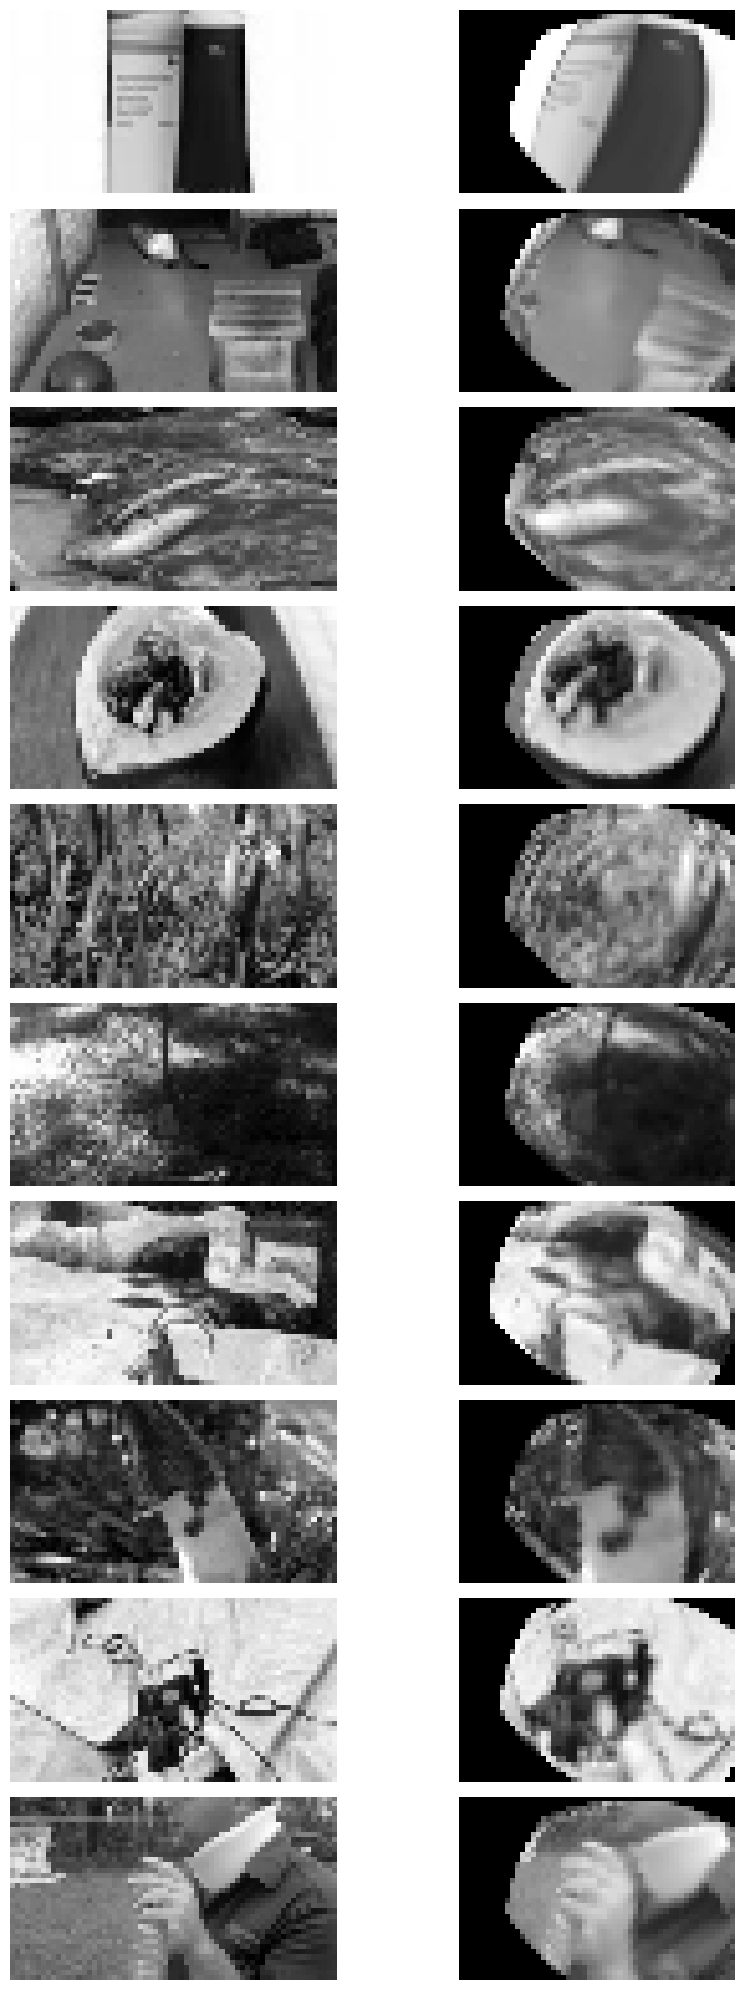

In [10]:
model.to(device)
data_key = "23343-5-17"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

imgs = batch.images[:, 0].detach().cpu()
out = model.perspective[data_key](batch.images, batch.pupil_center)[:, 0].detach().cpu()
print("img shape:", imgs.shape)
print("perspective output shape:", out.shape)

for i in range(10):
    ax[i, 0].imshow(imgs[i], cmap="gray")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(out[i], cmap="gray")
    ax[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
model.perspective[data_key].retina.mlp

Sequential(
  (0): ParametrizedLinear(
    in_features=2, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (1): GELU(approximate='none')
  (2): ParametrizedLinear(
    in_features=16, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (3): GELU(approximate='none')
  (4): ParametrizedLinear(
    in_features=16, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (5): GELU(approximate='none')
  (6): ParametrizedLinear(
    in_features=16, out_features=2, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
)

In [12]:
angles = model.perspective[data_key].retina.mlp(batch.pupil_center).detach().cpu().numpy()

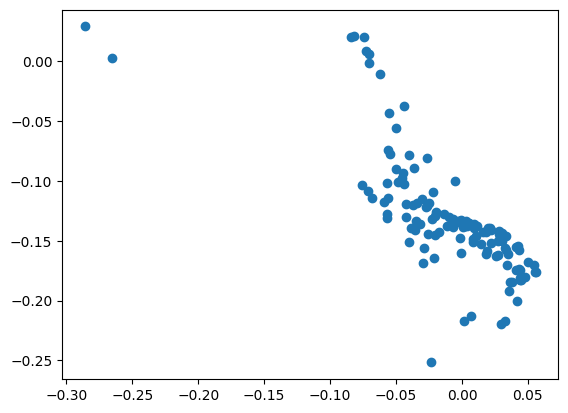

In [13]:
plt.scatter(angles[:, 0], angles[:, 1])